In [ ]:
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [ ]:
%%R
x1 = rnorm(100)
x2 = rnorm(100)
y = 2*x1 + 3*x2 + rnorm(100, sd=0.01)
x3 = x1 + x2 + rnorm(100, sd=0.0001)

In [ ]:
x1 = %R x1
x2 = %R x2
x3 = %R x3
y = %R y

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

In [ ]:
X = np.array([x1,x2,x3]).T

In [ ]:
classico = LinearRegression()
classico = classico.fit(X,y)
print(classico.coef_)
print(classico.intercept_)
print(classico.score(X,y))

[ 8.71418776  9.71384217 -6.71455183]
-0.0008105655140859813
0.9999946714087324


In [ ]:
X1 = sm.add_constant(X)
modelo_sm = sm.OLS(y, X1)
resultados = modelo_sm.fit()
resultados.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 6.005e+06
Date:                Thu, 23 Oct 2025   Prob (F-statistic):          5.94e-253
Time:                        12:11:07   Log-Likelihood:                 330.56
No. Observations:                 100   AIC:                            -653.1
Df Residuals:                      96   BIC:                            -642.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0008      0.001     -0.871      0.386      -0.003       0.001
x1             8.7142      8.619      1.011      0.315      -8.395      25.823
x2             9.7138      8.619      1.127      0.263      -7.395      26.822
x3            -6.7146      8.619     -0.779      0.438     -23.823      10.394
==============================================================================
Omnibus:                        0.993   Durbin-Watson:                   2.013
Prob(Omnibus):                  0.609   Jarque-Bera (JB):                0.950
Skew:                           0.037   Prob(JB):                        0.622
Kurtosis:                       2.528   Cond. No.                     3.10e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.1e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
from sklearn.linear_model import RidgeCV, LassoCV

In [ ]:
modelo_ridge = RidgeCV()
modelo_ridge.fit(X,y)
print(modelo_ridge.coef_)
print(modelo_ridge.intercept_)
print(modelo_ridge.score(X,y))

[0.33345789 1.33247488 1.66581461]
-0.0007482873014709179
0.9999945059865437


In [ ]:
modelo_lasso = LassoCV()
modelo_lasso.fit(X,y)
print(modelo_lasso.coef_)
print(modelo_lasso.intercept_)
print(modelo_lasso.score(X,y))

[0.         0.99517227 1.99936194]
-9.836395542683896e-05
0.9999927318055429


In [ ]:
bridge = pd.read_csv("https://github.com/cyshine/EstatESEG/raw/main/bridge.csv")

bridge.head()

,Case,Time,DArea,CCost,Dwgs,Length,Spans
0,1,78.8,3.60,82.4,6,90,1
1,2,309.5,5.33,422.3,12,126,2
2,3,184.5,6.29,179.8,9,78,1
3,4,69.6,2.20,100.0,5,60,1
4,5,68.8,1.44,103.0,5,60,1


In [ ]:
bridge.shape

(45, 7)

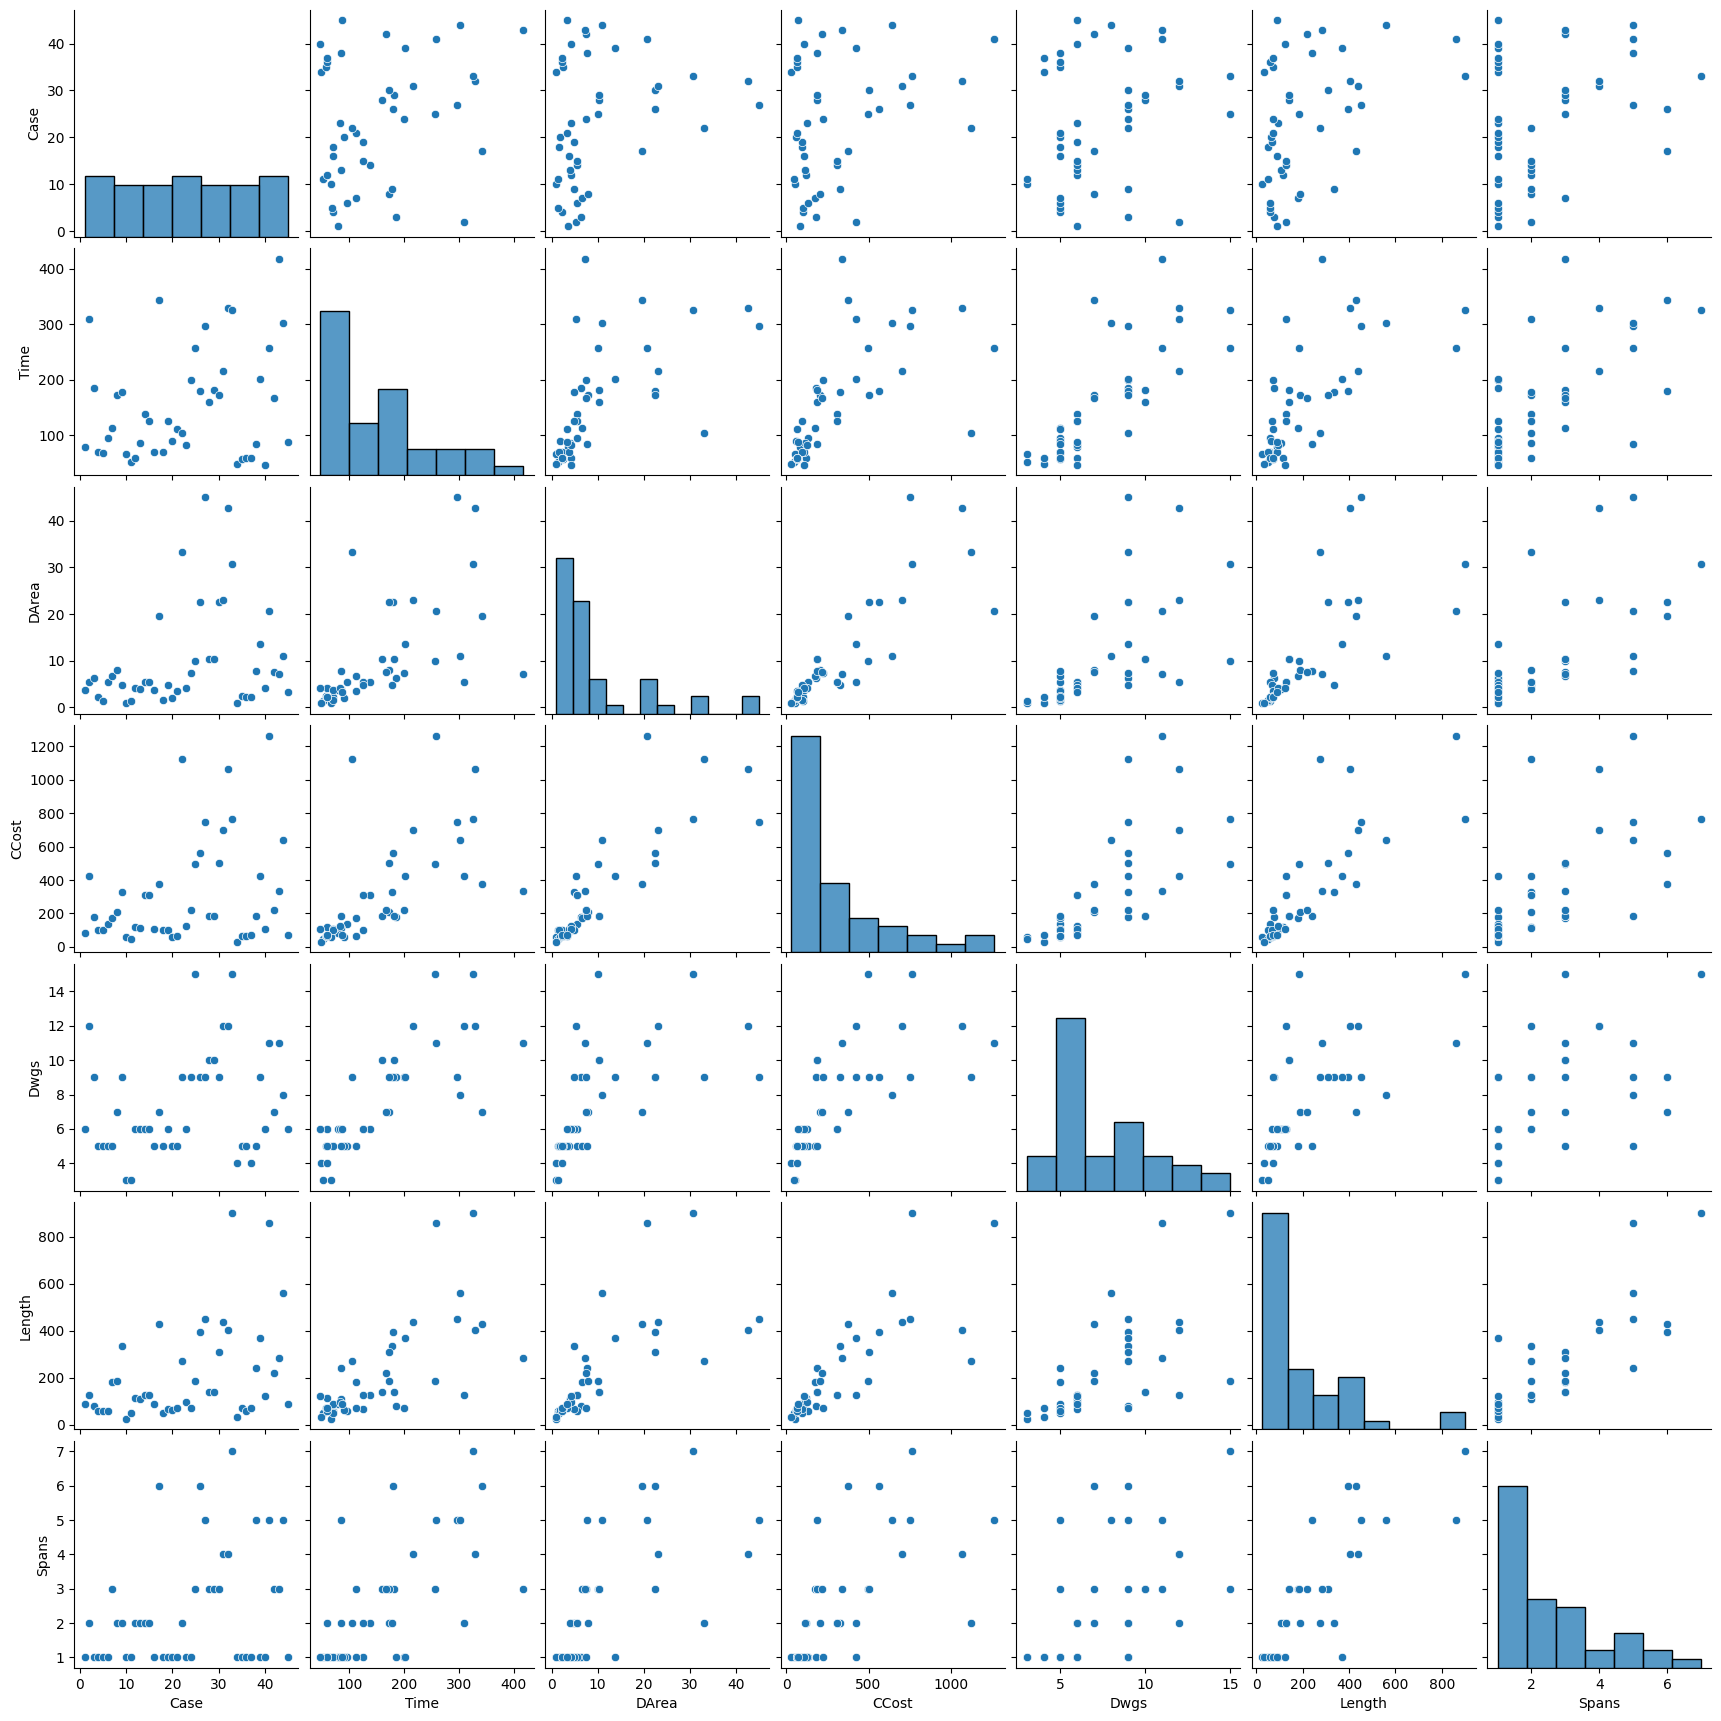

In [ ]:
sns.pairplot(bridge)

In [ ]:
import seaborn as sns

In [ ]:
ponte_scaler = StandardScaler()
ponte_scaler = ponte_scaler.fit(X)
X = ponte_scaler.transform(X)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error

# Select features and target variable
X_bridge = bridge[['DArea', 'CCost', 'Dwgs', 'Length', 'Spans']]
y_bridge = bridge['Time']

# Split data into training and testing sets (optional but good practice)
X_train, X_test, y_train, y_test = train_test_split(X_bridge, y_bridge, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Ridge Regression with Cross-Validation
ridge_model = RidgeCV(alphas = np.logspace(-6, 6, 13))
ridge_model.fit(X_train_scaled, y_train)

print("Ridge Regression Results:")
print("Best alpha:", ridge_model.alpha_)
print("Coefficients:", ridge_model.coef_)
print("Intercept:", ridge_model.intercept_)
print("R-squared (train):", ridge_model.score(X_train_scaled, y_train))
print("R-squared (test):", ridge_model.score(X_test_scaled, y_test))
y_pred_ridge = ridge_model.predict(X_test_scaled)
print("Mean Squared Error (test):", mean_squared_error(y_test, y_pred_ridge))

Ridge Regression Results:
Best alpha: 10.0
Coefficients: [ 3.48538387  2.66052765 44.20453706  9.65882286 19.49905153]
Intercept: 153.2
R-squared (train): 0.6801881360202475
R-squared (test): 0.7155791273263328
Mean Squared Error (test): 2406.352905997701


In [ ]:
# Lasso Regression with Cross-Validation
lasso_model = LassoCV(alphas = np.logspace(-6, 6, 13))
lasso_model.fit(X_train_scaled, y_train)

print("\nLasso Regression Results:")
print("Best alpha:", lasso_model.alpha_)
print("Coefficients:", lasso_model.coef_)
print("Intercept:", lasso_model.intercept_)
print("R-squared (train):", lasso_model.score(X_train_scaled, y_train))
print("R-squared (test):", lasso_model.score(X_test_scaled, y_test))
y_pred_lasso = lasso_model.predict(X_test_scaled)
print("Mean Squared Error (test):", mean_squared_error(y_test, y_pred_lasso))


Lasso Regression Results:
Best alpha: 10.0
Coefficients: [ 0.          0.         57.05732364  0.         19.32064647]
Intercept: 153.2
R-squared (train): 0.6944695008881897
R-squared (test): 0.6358209225344474
Mean Squared Error (test): 3081.1500334867287
